In [27]:
import pandas as pd
import matplotlib.pyplot as plt  # ← import correto

In [47]:
df_NE = pd.read_csv("/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/simulation_frac_100run1obsprob1.00/results_N_escapers_run1.csv")

### Numero de escapers NC = 0.25NE

### Numero de escapers NC = 0.50NE

### Numero de escapers NC = 0.25NE

Processando prob = 0.10...
  ✓ prob = 0.10: média final = 0.00 ± 0.00 (100 runs)
Processando prob = 0.20...
  ✓ prob = 0.20: média final = 0.00 ± 0.00 (100 runs)
Processando prob = 0.30...
  ✓ prob = 0.30: média final = 0.12 ± 0.35 (100 runs)
Processando prob = 0.40...
  ✓ prob = 0.40: média final = 0.34 ± 0.53 (100 runs)
Processando prob = 0.50...
  ✓ prob = 0.50: média final = 0.84 ± 0.86 (100 runs)
Processando prob = 0.60...
  ✓ prob = 0.60: média final = 1.59 ± 1.31 (100 runs)
Processando prob = 0.70...
  ✓ prob = 0.70: média final = 3.27 ± 1.68 (100 runs)
Processando prob = 0.80...
  ✓ prob = 0.80: média final = 4.82 ± 2.12 (100 runs)
Processando prob = 0.90...
  ✓ prob = 0.90: média final = 7.58 ± 2.53 (100 runs)
Processando prob = 1.00...
  ✓ prob = 1.00: média final = 10.18 ± 3.31 (100 runs)


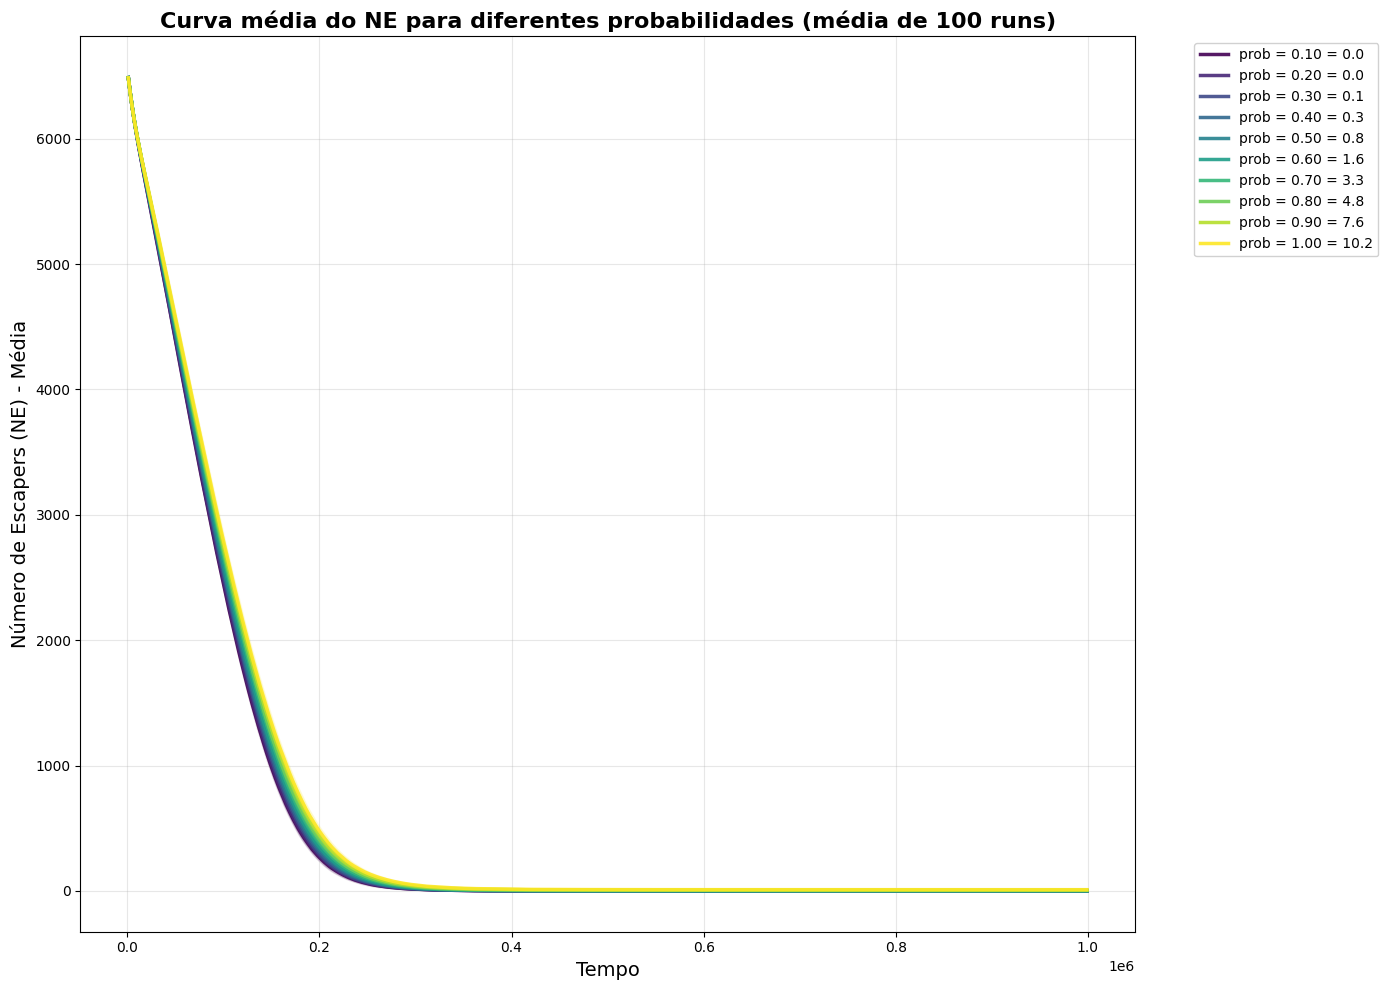


RESUMO DOS RESULTADOS
Probabilidade | Média Final  | Desvio Padrão | Runs  
------------------------------------------------------------
0.10          |       0.00 |        0.00 |  100
0.20          |       0.00 |        0.00 |  100
0.30          |       0.12 |        0.35 |  100
0.40          |       0.34 |        0.53 |  100
0.50          |       0.84 |        0.86 |  100
0.60          |       1.59 |        1.31 |  100
0.70          |       3.27 |        1.68 |  100
0.80          |       4.82 |        2.12 |  100
0.90          |       7.58 |        2.53 |  100
1.00          |      10.18 |        3.31 |  100


In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Lista de valores de prob (0.10 a 1.00 com passo 0.10)
prob_values = np.arange(0.10, 1.01, 0.10)

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva
cores = plt.cm.viridis(np.linspace(0, 1, len(prob_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada probabilidade
for idx, prob in enumerate(prob_values):
    todos_dados_NE = []
    
    print(f"Processando prob = {prob:.2f}...")
    
    # Ler todos os runs para esta probabilidade
    for run in range(1, num_runs + 1):
        try:
            caminho = f"{base_path}simulation_frac_25run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            todos_dados_NE.append(df_cortado[col_NE].values)
            
        except FileNotFoundError:
            continue
        except Exception as e:
            continue
    
    if todos_dados_NE:
        # Converter para array numpy
        todos_dados_NE = np.array(todos_dados_NE)
        
        # Calcular média
        media = np.mean(todos_dados_NE, axis=0)
        desvio_padrao = np.std(todos_dados_NE, axis=0)
        
        # Tempo (assumindo que é o mesmo para todos)
        tempo = df_cortado['time'].values
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[prob] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE)
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'prob = {prob:.2f} = {ultimo_valor:.1f}', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão (opcional, comente se quiser apenas as curvas)
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ prob = {prob:.2f}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[prob]['num_runs']} runs)")
    else:
        print(f"  ✗ prob = {prob:.2f}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title('Curva média do NE para diferentes probabilidades (média de 100 runs)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*60)
print("RESUMO DOS RESULTADOS")
print("="*60)
print(f"{'Probabilidade':<12} | {'Média Final':<12} | {'Desvio Padrão':<12} | {'Runs':<6}")
print("-"*60)
for prob in sorted(resultados.keys()):
    stats = resultados[prob]
    print(f"{prob:.2f}          | {stats['media_final']:>10.2f} | {stats['std_final']:>11.2f} | {stats['num_runs']:>4}")
print("="*60)

### Numero de escapers NC = 0.50NE

Processando prob = 0.10...
  ✓ prob = 0.10: média final = 0.00 ± 0.00 (100 runs)
Processando prob = 0.20...
  ✓ prob = 0.20: média final = 0.01 ± 0.10 (100 runs)
Processando prob = 0.30...
  ✓ prob = 0.30: média final = 0.18 ± 0.38 (100 runs)
Processando prob = 0.40...
  ✓ prob = 0.40: média final = 0.32 ± 0.53 (100 runs)
Processando prob = 0.50...
  ✓ prob = 0.50: média final = 0.97 ± 0.95 (100 runs)
Processando prob = 0.60...
  ✓ prob = 0.60: média final = 1.83 ± 1.24 (100 runs)
Processando prob = 0.70...
  ✓ prob = 0.70: média final = 3.44 ± 1.99 (100 runs)
Processando prob = 0.80...
  ✓ prob = 0.80: média final = 4.60 ± 2.21 (100 runs)
Processando prob = 0.90...
  ✓ prob = 0.90: média final = 7.49 ± 2.67 (100 runs)
Processando prob = 1.00...
  ✓ prob = 1.00: média final = 10.49 ± 3.46 (100 runs)


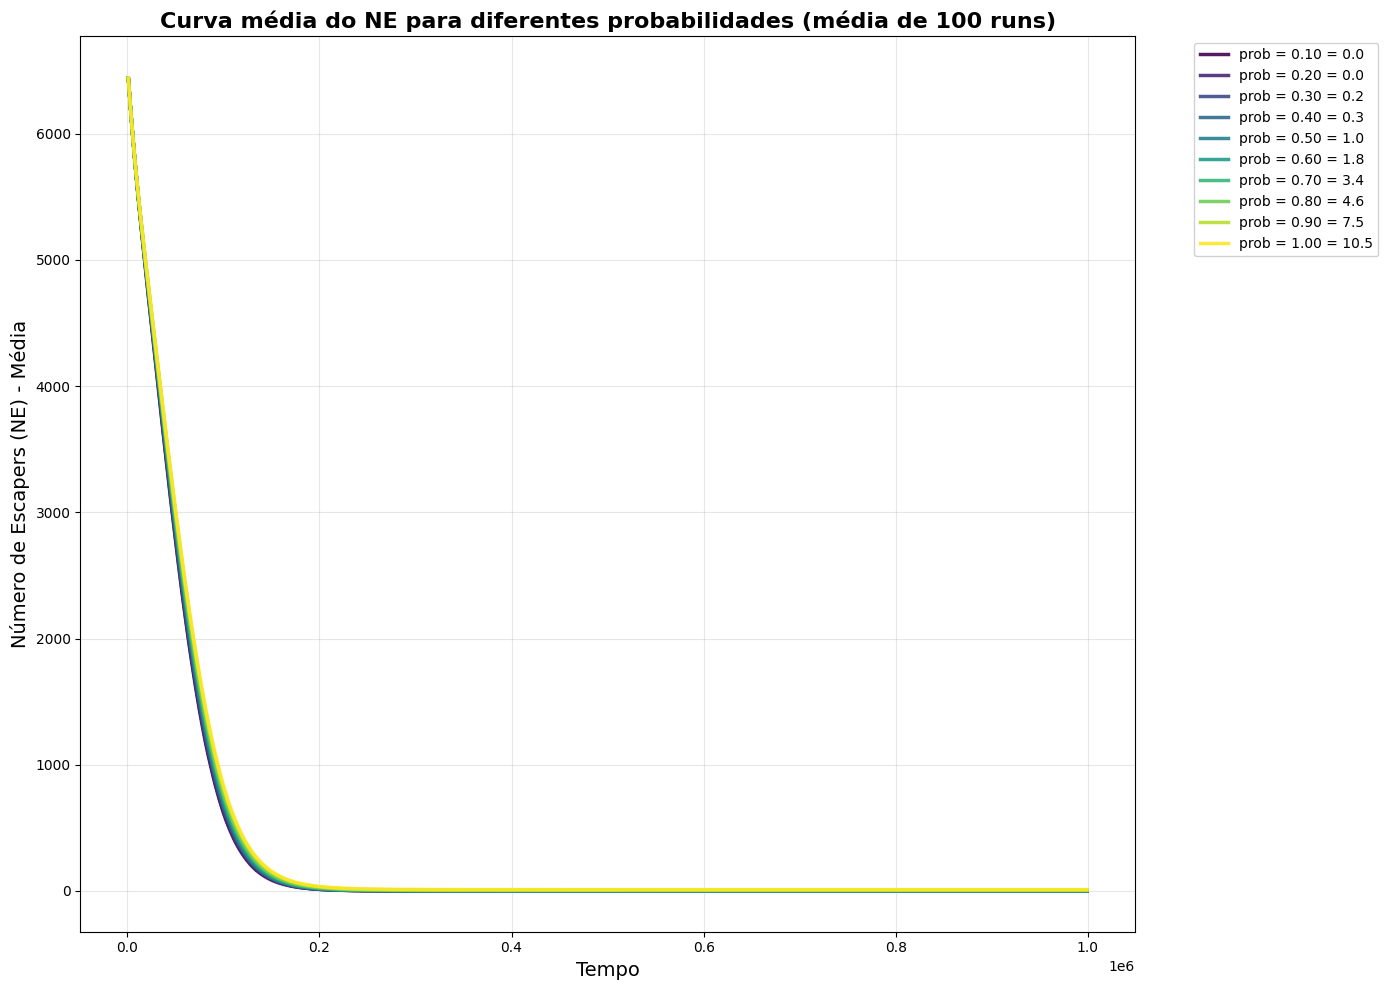


RESUMO DOS RESULTADOS
Probabilidade | Média Final  | Desvio Padrão | Runs  
------------------------------------------------------------
0.10          |       0.00 |        0.00 |  100
0.20          |       0.01 |        0.10 |  100
0.30          |       0.18 |        0.38 |  100
0.40          |       0.32 |        0.53 |  100
0.50          |       0.97 |        0.95 |  100
0.60          |       1.83 |        1.24 |  100
0.70          |       3.44 |        1.99 |  100
0.80          |       4.60 |        2.21 |  100
0.90          |       7.49 |        2.67 |  100
1.00          |      10.49 |        3.46 |  100


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Lista de valores de prob (0.10 a 1.00 com passo 0.10)
prob_values = np.arange(0.10, 1.01, 0.10)

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva
cores = plt.cm.viridis(np.linspace(0, 1, len(prob_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada probabilidade
for idx, prob in enumerate(prob_values):
    todos_dados_NE = []
    
    print(f"Processando prob = {prob:.2f}...")
    
    # Ler todos os runs para esta probabilidade
    for run in range(1, num_runs + 1):
        try:
            caminho = f"{base_path}simulation_frac_50run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            todos_dados_NE.append(df_cortado[col_NE].values)
            
        except FileNotFoundError:
            continue
        except Exception as e:
            continue
    
    if todos_dados_NE:
        # Converter para array numpy
        todos_dados_NE = np.array(todos_dados_NE)
        
        # Calcular média
        media = np.mean(todos_dados_NE, axis=0)
        desvio_padrao = np.std(todos_dados_NE, axis=0)
        
        # Tempo (assumindo que é o mesmo para todos)
        tempo = df_cortado['time'].values
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[prob] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE)
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'prob = {prob:.2f} = {ultimo_valor:.1f}', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão (opcional, comente se quiser apenas as curvas)
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ prob = {prob:.2f}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[prob]['num_runs']} runs)")
    else:
        print(f"  ✗ prob = {prob:.2f}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title('Curva média do NE para diferentes probabilidades (média de 100 runs)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*60)
print("RESUMO DOS RESULTADOS")
print("="*60)
print(f"{'Probabilidade':<12} | {'Média Final':<12} | {'Desvio Padrão':<12} | {'Runs':<6}")
print("-"*60)
for prob in sorted(resultados.keys()):
    stats = resultados[prob]
    print(f"{prob:.2f}          | {stats['media_final']:>10.2f} | {stats['std_final']:>11.2f} | {stats['num_runs']:>4}")
print("="*60)

### Numero de escapers NC = 1.00NE

Processando prob = 0.10...
  ✓ prob = 0.10: média final = 0.00 ± 0.00 (100 runs)
Processando prob = 0.20...
  ✓ prob = 0.20: média final = 0.01 ± 0.10 (100 runs)
Processando prob = 0.30...
  ✓ prob = 0.30: média final = 0.08 ± 0.31 (100 runs)
Processando prob = 0.40...
  ✓ prob = 0.40: média final = 0.35 ± 0.52 (100 runs)
Processando prob = 0.50...
  ✓ prob = 0.50: média final = 0.71 ± 0.84 (100 runs)
Processando prob = 0.60...
  ✓ prob = 0.60: média final = 1.78 ± 1.46 (100 runs)
Processando prob = 0.70...
  ✓ prob = 0.70: média final = 2.91 ± 1.88 (100 runs)
Processando prob = 0.80...
  ✓ prob = 0.80: média final = 4.39 ± 2.12 (100 runs)
Processando prob = 0.90...
  ✓ prob = 0.90: média final = 6.35 ± 2.23 (100 runs)
Processando prob = 1.00...
  ✓ prob = 1.00: média final = 10.22 ± 3.44 (100 runs)


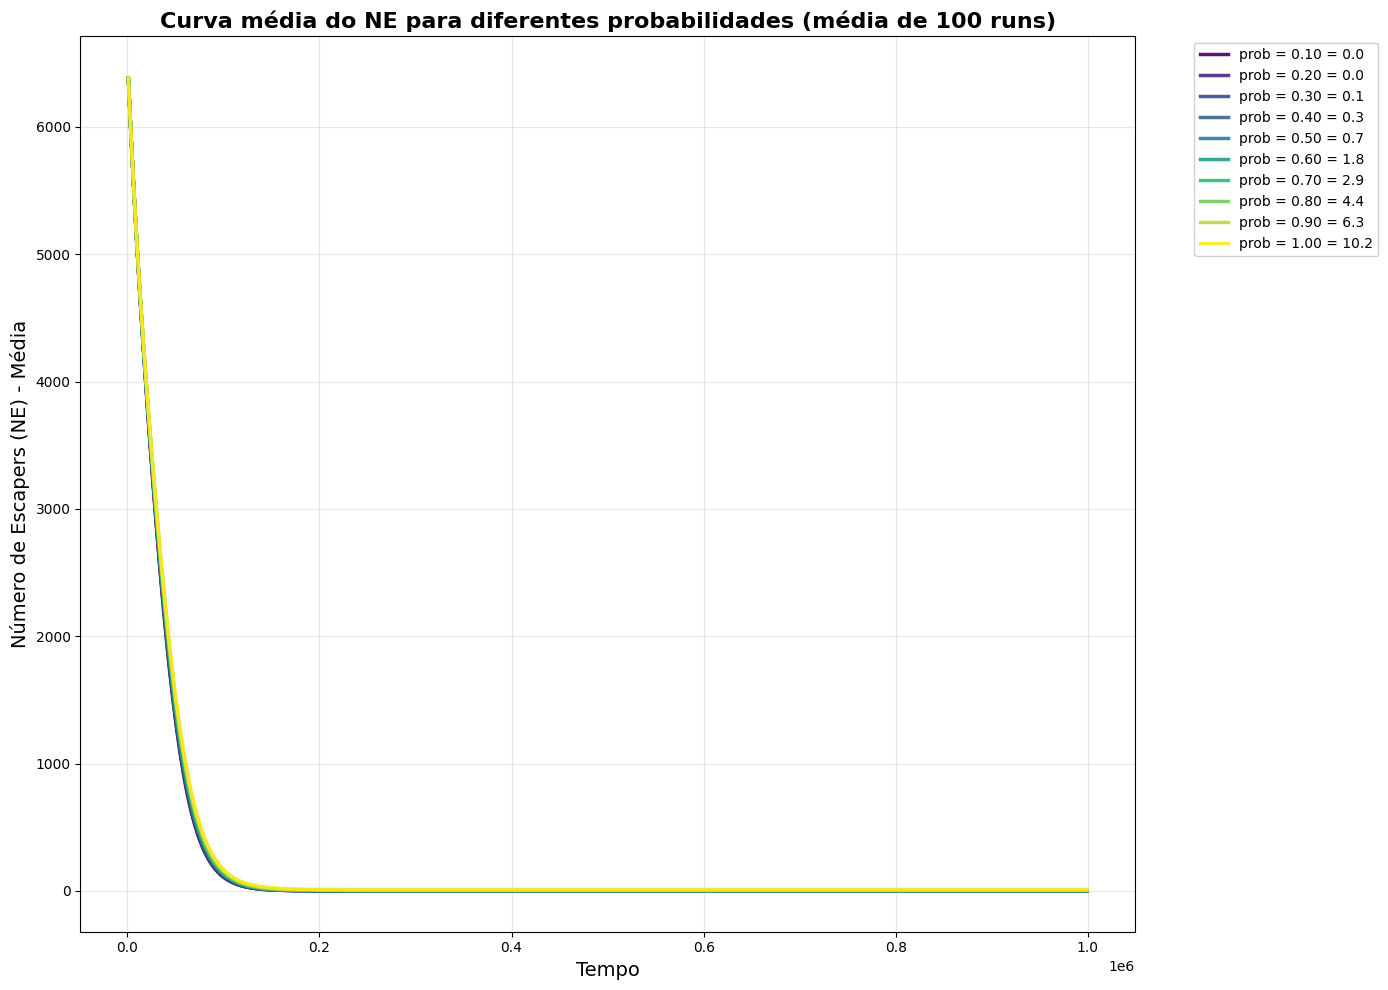


RESUMO DOS RESULTADOS
Probabilidade | Média Final  | Desvio Padrão | Runs  
------------------------------------------------------------
0.10          |       0.00 |        0.00 |  100
0.20          |       0.01 |        0.10 |  100
0.30          |       0.08 |        0.31 |  100
0.40          |       0.35 |        0.52 |  100
0.50          |       0.71 |        0.84 |  100
0.60          |       1.78 |        1.46 |  100
0.70          |       2.91 |        1.88 |  100
0.80          |       4.39 |        2.12 |  100
0.90          |       6.35 |        2.23 |  100
1.00          |      10.22 |        3.44 |  100


In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Lista de valores de prob (0.10 a 1.00 com passo 0.10)
prob_values = np.arange(0.10, 1.01, 0.10)

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva
cores = plt.cm.viridis(np.linspace(0, 1, len(prob_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada probabilidade
for idx, prob in enumerate(prob_values):
    todos_dados_NE = []
    
    print(f"Processando prob = {prob:.2f}...")
    
    # Ler todos os runs para esta probabilidade
    for run in range(1, num_runs + 1):
        try:
            caminho = f"{base_path}simulation_frac_100run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            todos_dados_NE.append(df_cortado[col_NE].values)
            
        except FileNotFoundError:
            continue
        except Exception as e:
            continue
    
    if todos_dados_NE:
        # Converter para array numpy
        todos_dados_NE = np.array(todos_dados_NE)
        
        # Calcular média
        media = np.mean(todos_dados_NE, axis=0)
        desvio_padrao = np.std(todos_dados_NE, axis=0)
        
        # Tempo (assumindo que é o mesmo para todos)
        tempo = df_cortado['time'].values
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[prob] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE)
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'prob = {prob:.2f} = {ultimo_valor:.1f}', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão (opcional, comente se quiser apenas as curvas)
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ prob = {prob:.2f}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[prob]['num_runs']} runs)")
    else:
        print(f"  ✗ prob = {prob:.2f}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title('Curva média do NE para diferentes probabilidades (média de 100 runs)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*60)
print("RESUMO DOS RESULTADOS")
print("="*60)
print(f"{'Probabilidade':<12} | {'Média Final':<12} | {'Desvio Padrão':<12} | {'Runs':<6}")
print("-"*60)
for prob in sorted(resultados.keys()):
    stats = resultados[prob]
    print(f"{prob:.2f}          | {stats['media_final']:>10.2f} | {stats['std_final']:>11.2f} | {stats['num_runs']:>4}")
print("="*60)

In [ ]:
### Numero de escapers NC = 0.25NE

Processando prob = 0.10...
  ✓ prob = 0.10: média final = 581.01 ± 24.01 (100 runs, comprimento=998)
Processando prob = 0.20...
  ✓ prob = 0.20: média final = 1150.24 ± 35.89 (100 runs, comprimento=998)
Processando prob = 0.30...
  ✓ prob = 0.30: média final = 1714.37 ± 43.23 (100 runs, comprimento=998)
Processando prob = 0.40...
  ✓ prob = 0.40: média final = 2266.38 ± 56.89 (100 runs, comprimento=998)
Processando prob = 0.50...
  ✓ prob = 0.50: média final = 2800.11 ± 61.67 (100 runs, comprimento=998)
Processando prob = 0.60...
  ✓ prob = 0.60: média final = 3322.08 ± 65.62 (100 runs, comprimento=998)
Processando prob = 0.70...
  ✓ prob = 0.70: média final = 3846.60 ± 74.24 (100 runs, comprimento=998)
Processando prob = 0.80...
  ✓ prob = 0.80: média final = 4370.52 ± 79.13 (100 runs, comprimento=998)
Processando prob = 0.90...
  ✓ prob = 0.90: média final = 4874.16 ± 81.43 (100 runs, comprimento=998)
Processando prob = 1.00...
  ✓ prob = 1.00: média final = 5373.78 ± 85.47 (100 runs

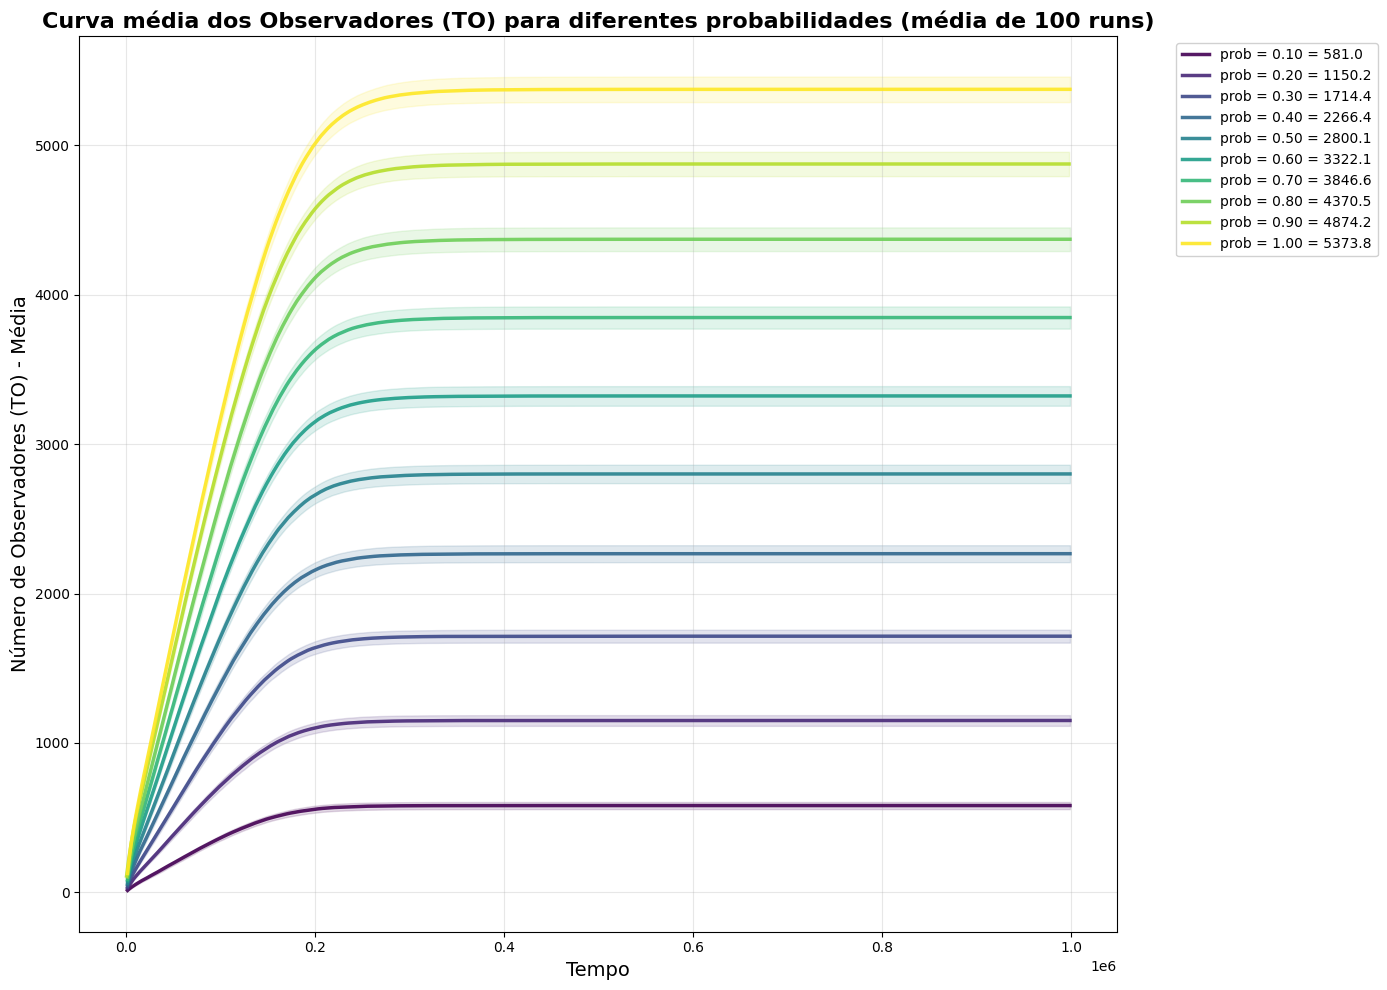


RESUMO DOS RESULTADOS - OBSERVADORES (TO)
Probabilidade | Média Final  | Desvio Padrão | Runs   | Tamanho 
----------------------------------------------------------------------
0.10          |     581.01 |       24.01 |  100 |      998
0.20          |    1150.24 |       35.89 |  100 |      998
0.30          |    1714.37 |       43.23 |  100 |      998
0.40          |    2266.38 |       56.89 |  100 |      998
0.50          |    2800.11 |       61.67 |  100 |      998
0.60          |    3322.08 |       65.62 |  100 |      998
0.70          |    3846.60 |       74.24 |  100 |      998
0.80          |    4370.52 |       79.13 |  100 |      998
0.90          |    4874.16 |       81.43 |  100 |      998
1.00          |    5373.78 |       85.47 |  100 |      998


In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Lista de valores de prob (0.10 a 1.00 com passo 0.10)
prob_values = np.arange(0.10, 1.01, 0.10)

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva
cores = plt.cm.viridis(np.linspace(0, 1, len(prob_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada probabilidade
for idx, prob in enumerate(prob_values):
    todos_dados_TO = []
    tempos = []
    
    print(f"Processando prob = {prob:.2f}...")
    
    # Ler todos os runs para esta probabilidade
    for run in range(1, num_runs + 1):
        try:
            caminho = f"{base_path}simulation_frac_25run{run}obsprob{prob:.2f}/results_N_obs{run}.csv"
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_TO = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores e o tempo
            valores = df_cortado[col_TO].values
            tempo = df_cortado['time'].values
            
            todos_dados_TO.append(valores)
            tempos.append(tempo)
            
        except FileNotFoundError:
            continue
        except Exception as e:
            continue
    
    if todos_dados_TO:
        # Encontrar o menor comprimento entre todos os arrays
        min_len = min(len(arr) for arr in todos_dados_TO)
        
        # Cortar todos os arrays para o mesmo comprimento
        todos_dados_TO_cortados = [arr[:min_len] for arr in todos_dados_TO]
        
        # Converter para array numpy
        todos_dados_TO_array = np.array(todos_dados_TO_cortados)
        
        # Usar o tempo do primeiro array (cortado)
        tempo = tempos[0][:min_len]
        
        # Calcular média e desvio padrão
        media = np.mean(todos_dados_TO_array, axis=0)
        desvio_padrao = np.std(todos_dados_TO_array, axis=0)
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[prob] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_TO),
            'min_len': min_len
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'prob = {prob:.2f} = {ultimo_valor:.1f}', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ prob = {prob:.2f}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[prob]['num_runs']} runs, comprimento={min_len})")
    else:
        print(f"  ✗ prob = {prob:.2f}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Observadores (TO) - Média', fontsize=14)
plt.title('Curva média dos Observadores (TO) para diferentes probabilidades (média de 100 runs)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*70)
print("RESUMO DOS RESULTADOS - OBSERVADORES (TO)")
print("="*70)
print(f"{'Probabilidade':<12} | {'Média Final':<12} | {'Desvio Padrão':<12} | {'Runs':<6} | {'Tamanho':<8}")
print("-"*70)
for prob in sorted(resultados.keys()):
    stats = resultados[prob]
    print(f"{prob:.2f}          | {stats['media_final']:>10.2f} | {stats['std_final']:>11.2f} | {stats['num_runs']:>4} | {stats['min_len']:>8}")
print("="*70)

Processando prob = 0.10...
  ✓ prob = 0.10: média final = 557.05 ± 21.50 (100 runs, comprimento=998)
Processando prob = 0.20...
  ✓ prob = 0.20: média final = 1090.60 ± 35.48 (100 runs, comprimento=998)
Processando prob = 0.30...
  ✓ prob = 0.30: média final = 1631.95 ± 44.45 (100 runs, comprimento=998)
Processando prob = 0.40...
  ✓ prob = 0.40: média final = 2144.74 ± 46.67 (100 runs, comprimento=998)
Processando prob = 0.50...
  ✓ prob = 0.50: média final = 2648.20 ± 58.19 (100 runs, comprimento=998)
Processando prob = 0.60...
  ✓ prob = 0.60: média final = 3136.10 ± 62.95 (100 runs, comprimento=998)
Processando prob = 0.70...
  ✓ prob = 0.70: média final = 3630.86 ± 68.43 (100 runs, comprimento=998)
Processando prob = 0.80...
  ✓ prob = 0.80: média final = 4110.73 ± 82.00 (100 runs, comprimento=998)
Processando prob = 0.90...
  ✓ prob = 0.90: média final = 4598.19 ± 87.30 (100 runs, comprimento=998)
Processando prob = 1.00...
  ✓ prob = 1.00: média final = 5028.37 ± 86.18 (100 runs

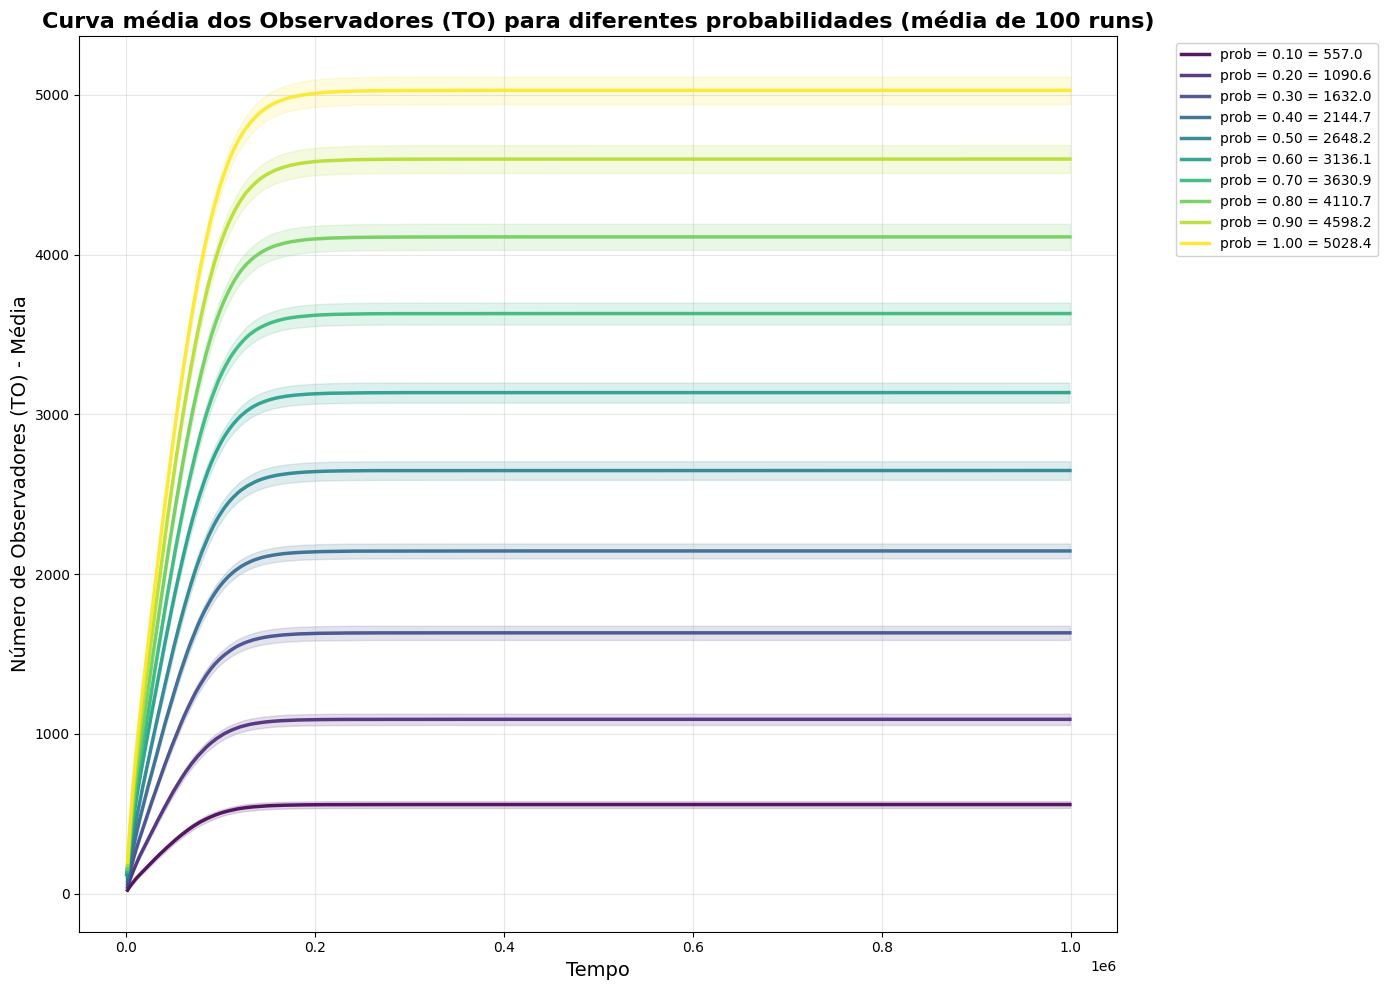


RESUMO DOS RESULTADOS - OBSERVADORES (TO)
Probabilidade | Média Final  | Desvio Padrão | Runs   | Tamanho 
----------------------------------------------------------------------
0.10          |     557.05 |       21.50 |  100 |      998
0.20          |    1090.60 |       35.48 |  100 |      998
0.30          |    1631.95 |       44.45 |  100 |      998
0.40          |    2144.74 |       46.67 |  100 |      998
0.50          |    2648.20 |       58.19 |  100 |      998
0.60          |    3136.10 |       62.95 |  100 |      998
0.70          |    3630.86 |       68.43 |  100 |      998
0.80          |    4110.73 |       82.00 |  100 |      998
0.90          |    4598.19 |       87.30 |  100 |      998
1.00          |    5028.37 |       86.18 |  100 |      998


In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Lista de valores de prob (0.10 a 1.00 com passo 0.10)
prob_values = np.arange(0.10, 1.01, 0.10)

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva
cores = plt.cm.viridis(np.linspace(0, 1, len(prob_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada probabilidade
for idx, prob in enumerate(prob_values):
    todos_dados_TO = []
    tempos = []
    
    print(f"Processando prob = {prob:.2f}...")
    
    # Ler todos os runs para esta probabilidade
    for run in range(1, num_runs + 1):
        try:
            caminho = f"{base_path}simulation_frac_50run{run}obsprob{prob:.2f}/results_N_obs{run}.csv"
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_TO = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores e o tempo
            valores = df_cortado[col_TO].values
            tempo = df_cortado['time'].values
            
            todos_dados_TO.append(valores)
            tempos.append(tempo)
            
        except FileNotFoundError:
            continue
        except Exception as e:
            continue
    
    if todos_dados_TO:
        # Encontrar o menor comprimento entre todos os arrays
        min_len = min(len(arr) for arr in todos_dados_TO)
        
        # Cortar todos os arrays para o mesmo comprimento
        todos_dados_TO_cortados = [arr[:min_len] for arr in todos_dados_TO]
        
        # Converter para array numpy
        todos_dados_TO_array = np.array(todos_dados_TO_cortados)
        
        # Usar o tempo do primeiro array (cortado)
        tempo = tempos[0][:min_len]
        
        # Calcular média e desvio padrão
        media = np.mean(todos_dados_TO_array, axis=0)
        desvio_padrao = np.std(todos_dados_TO_array, axis=0)
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[prob] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_TO),
            'min_len': min_len
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'prob = {prob:.2f} = {ultimo_valor:.1f}', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ prob = {prob:.2f}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[prob]['num_runs']} runs, comprimento={min_len})")
    else:
        print(f"  ✗ prob = {prob:.2f}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Observadores (TO) - Média', fontsize=14)
plt.title('Curva média dos Observadores (TO) para diferentes probabilidades (média de 100 runs)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*70)
print("RESUMO DOS RESULTADOS - OBSERVADORES (TO)")
print("="*70)
print(f"{'Probabilidade':<12} | {'Média Final':<12} | {'Desvio Padrão':<12} | {'Runs':<6} | {'Tamanho':<8}")
print("-"*70)
for prob in sorted(resultados.keys()):
    stats = resultados[prob]
    print(f"{prob:.2f}          | {stats['media_final']:>10.2f} | {stats['std_final']:>11.2f} | {stats['num_runs']:>4} | {stats['min_len']:>8}")
print("="*70)

Processando prob = 0.10...
  ✓ prob = 0.10: média final = 499.08 ± 24.76 (100 runs, comprimento=998)
Processando prob = 0.20...
  ✓ prob = 0.20: média final = 982.11 ± 28.95 (100 runs, comprimento=998)
Processando prob = 0.30...
  ✓ prob = 0.30: média final = 1448.44 ± 39.94 (100 runs, comprimento=998)
Processando prob = 0.40...
  ✓ prob = 0.40: média final = 1898.23 ± 46.03 (100 runs, comprimento=998)
Processando prob = 0.50...
  ✓ prob = 0.50: média final = 2343.05 ± 49.87 (100 runs, comprimento=998)
Processando prob = 0.60...
  ✓ prob = 0.60: média final = 2767.11 ± 59.55 (100 runs, comprimento=998)
Processando prob = 0.70...
  ✓ prob = 0.70: média final = 3194.27 ± 56.24 (100 runs, comprimento=998)
Processando prob = 0.80...
  ✓ prob = 0.80: média final = 3612.86 ± 66.95 (100 runs, comprimento=998)
Processando prob = 0.90...
  ✓ prob = 0.90: média final = 4013.25 ± 82.09 (100 runs, comprimento=998)
Processando prob = 1.00...
  ✓ prob = 1.00: média final = 4402.63 ± 72.93 (100 runs,

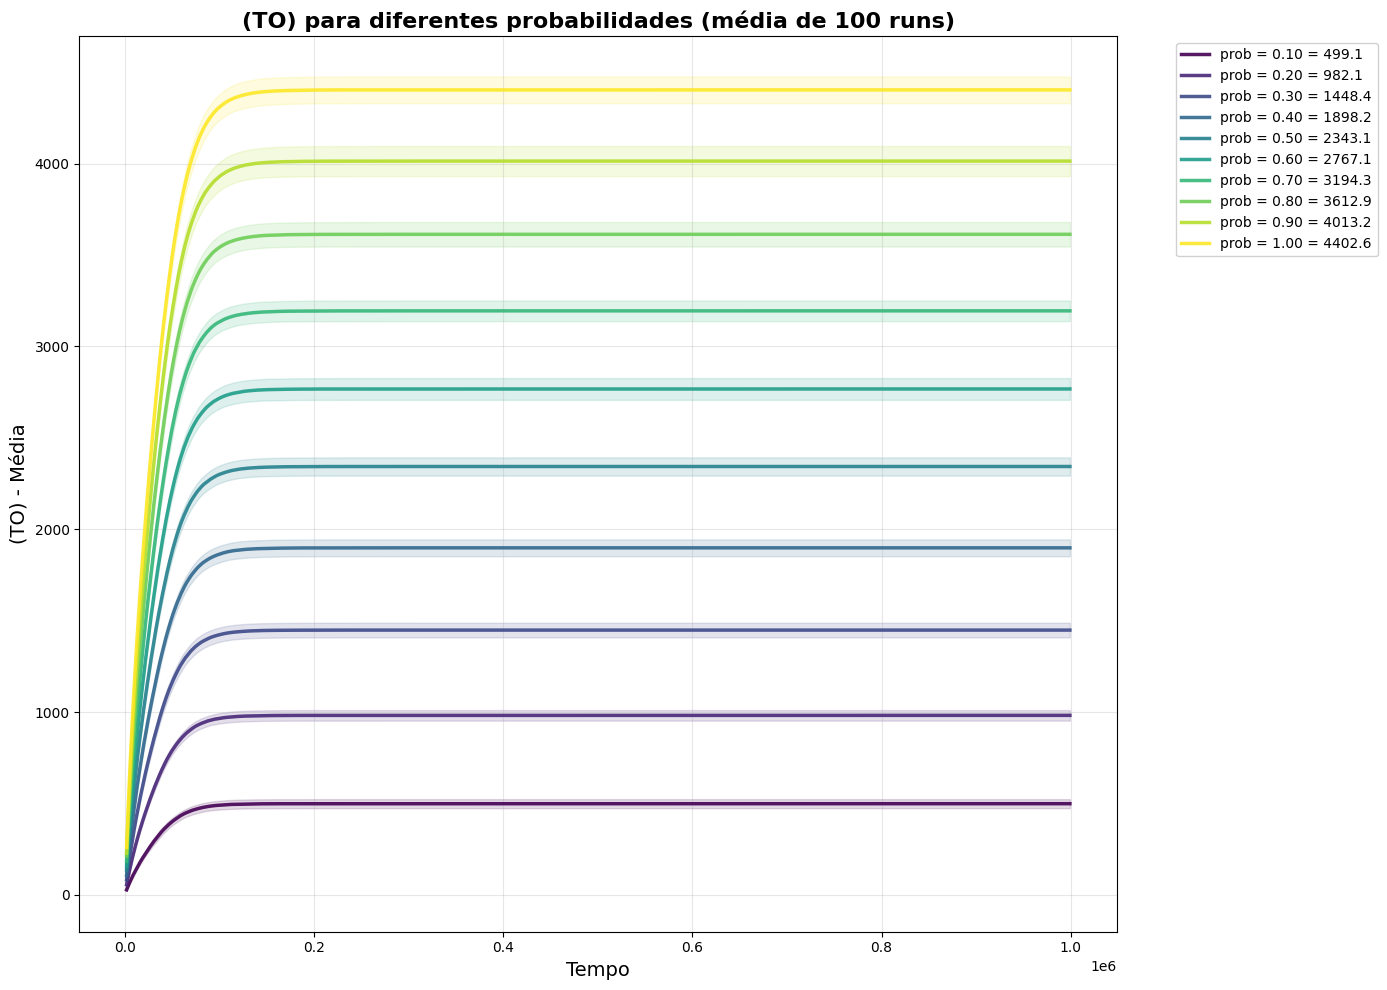


RESUMO DOS RESULTADOS - OBSERVADORES (TO)
Probabilidade | Média Final  | Desvio Padrão | Runs   | Tamanho 
----------------------------------------------------------------------
0.10          |     499.08 |       24.76 |  100 |      998
0.20          |     982.11 |       28.95 |  100 |      998
0.30          |    1448.44 |       39.94 |  100 |      998
0.40          |    1898.23 |       46.03 |  100 |      998
0.50          |    2343.05 |       49.87 |  100 |      998
0.60          |    2767.11 |       59.55 |  100 |      998
0.70          |    3194.27 |       56.24 |  100 |      998
0.80          |    3612.86 |       66.95 |  100 |      998
0.90          |    4013.25 |       82.09 |  100 |      998
1.00          |    4402.63 |       72.93 |  100 |      998


In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Lista de valores de prob (0.10 a 1.00 com passo 0.10)
prob_values = np.arange(0.10, 1.01, 0.10)

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva
cores = plt.cm.viridis(np.linspace(0, 1, len(prob_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada probabilidade
for idx, prob in enumerate(prob_values):
    todos_dados_TO = []
    tempos = []
    
    print(f"Processando prob = {prob:.2f}...")
    
    # Ler todos os runs para esta probabilidade
    for run in range(1, num_runs + 1):
        try:
            caminho = f"{base_path}simulation_frac_100run{run}obsprob{prob:.2f}/results_N_obs{run}.csv"
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_TO = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores e o tempo
            valores = df_cortado[col_TO].values
            tempo = df_cortado['time'].values
            
            todos_dados_TO.append(valores)
            tempos.append(tempo)
            
        except FileNotFoundError:
            continue
        except Exception as e:
            continue
    
    if todos_dados_TO:
        # Encontrar o menor comprimento entre todos os arrays
        min_len = min(len(arr) for arr in todos_dados_TO)
        
        # Cortar todos os arrays para o mesmo comprimento
        todos_dados_TO_cortados = [arr[:min_len] for arr in todos_dados_TO]
        
        # Converter para array numpy
        todos_dados_TO_array = np.array(todos_dados_TO_cortados)
        
        # Usar o tempo do primeiro array (cortado)
        tempo = tempos[0][:min_len]
        
        # Calcular média e desvio padrão
        media = np.mean(todos_dados_TO_array, axis=0)
        desvio_padrao = np.std(todos_dados_TO_array, axis=0)
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[prob] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_TO),
            'min_len': min_len
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'prob = {prob:.2f} = {ultimo_valor:.1f}', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ prob = {prob:.2f}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[prob]['num_runs']} runs, comprimento={min_len})")
    else:
        print(f"  ✗ prob = {prob:.2f}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('(TO) - Média', fontsize=14)
plt.title('(TO) para diferentes probabilidades (média de 100 runs)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*70)
print("RESUMO DOS RESULTADOS - OBSERVADORES (TO)")
print("="*70)
print(f"{'Probabilidade':<12} | {'Média Final':<12} | {'Desvio Padrão':<12} | {'Runs':<6} | {'Tamanho':<8}")
print("-"*70)
for prob in sorted(resultados.keys()):
    stats = resultados[prob]
    print(f"{prob:.2f}          | {stats['media_final']:>10.2f} | {stats['std_final']:>11.2f} | {stats['num_runs']:>4} | {stats['min_len']:>8}")
print("="*70)

Carregando dados para prob = 0.60...

FIT WEIBULL COM RESTRIÇÃO C ≥ 0 - prob = 0.60
Parâmetros encontrados (fisicamente realistas):
  A = 6440.1300
  τ = 57247.8532
  β = 1.3427
  C = 0.0000 (assíntota final, NÃO negativa)
  R² = 0.9987
  N(0) = 6440.13 (fixo)
  N(∞) = 0.00


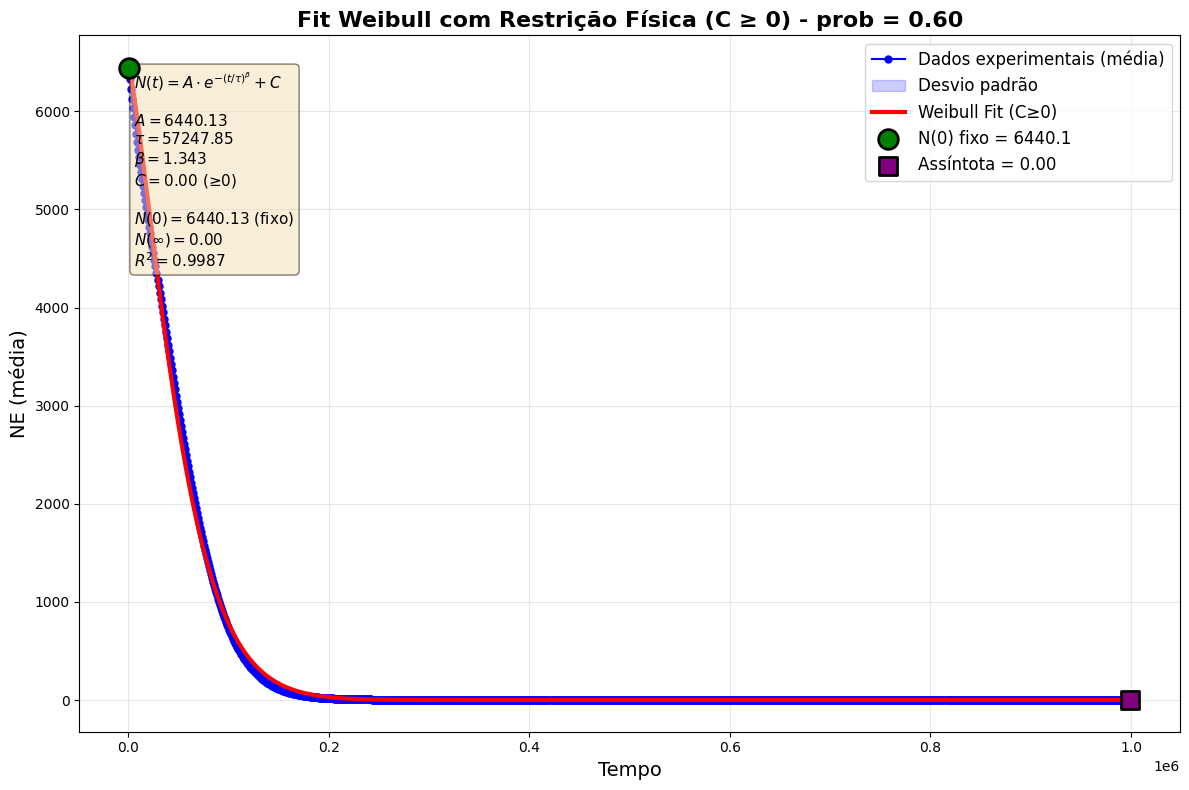

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Probabilidade específica
prob = 0.60
num_runs = 100

# Carregar dados
todos_dados_NE = []
tempos = []

print(f"Carregando dados para prob = {prob:.2f}...")

for run in range(1, num_runs + 1):
    try:
        caminho = f"{base_path}simulation_frac_50run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
        df = pd.read_csv(caminho)
        df_cortado = df.iloc[1:].reset_index(drop=True)
        col_NE = [col for col in df_cortado.columns if col != 'time'][0]
        
        valores = df_cortado[col_NE].values
        tempo = df_cortado['time'].values
        
        todos_dados_NE.append(valores)
        tempos.append(tempo)
    except:
        continue

if todos_dados_NE:
    min_len = min(len(arr) for arr in todos_dados_NE)
    todos_dados_NE_cortados = [arr[:min_len] for arr in todos_dados_NE]
    todos_dados_NE_array = np.array(todos_dados_NE_cortados)
    
    media = np.mean(todos_dados_NE_array, axis=0)
    desvio = np.std(todos_dados_NE_array, axis=0)
    tempo = tempos[0][:min_len]
    
    # Função com restrição C >= 0
    def weibull_decay_constrained(t, tau, beta, C):
        """Força C >= 0"""
        if C < 0:
            return np.inf  # Penaliza valores negativos
        A = media[0] - C
        if A < 0:
            return np.inf  # A também não pode ser negativo
        return A * np.exp(-(t / tau)**beta) + C
    
    # Chutes iniciais
    C_guess = max(media[-1], 0)  # Garantir que o chute inicial não seja negativo
    tau_guess = tempo[len(tempo)//2]
    beta_guess = 1.5
    
    # Fit com bounds (limites)
    try:
        # Usar bounds para garantir C >= 0
        popt, pcov = curve_fit(
            lambda t, tau, beta, C: (media[0] - max(C, 0)) * np.exp(-(t / tau)**beta) + max(C, 0),
            tempo, media,
            p0=[tau_guess, beta_guess, C_guess],
            bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),  # τ>0, β>0, C>=0
            maxfev=5000
        )
        
        tau_fit, beta_fit, C_fit = popt
        A_fit = media[0] - C_fit
        
        # Garantir que C não é negativo (por segurança)
        C_fit = max(C_fit, 0)
        A_fit = max(A_fit, 0)
        
        # Gerar curva ajustada
        tempo_fit = np.linspace(min(tempo), max(tempo), 500)
        media_fit = A_fit * np.exp(-(tempo_fit / tau_fit)**beta_fit) + C_fit
        
        # Calcular R²
        residuos = media - (A_fit * np.exp(-(tempo / tau_fit)**beta_fit) + C_fit)
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((media - np.mean(media))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        print("\n" + "="*70)
        print(f"FIT WEIBULL COM RESTRIÇÃO C ≥ 0 - prob = {prob:.2f}")
        print("="*70)
        print(f"Parâmetros encontrados (fisicamente realistas):")
        print(f"  A = {A_fit:.4f}")
        print(f"  τ = {tau_fit:.4f}")
        print(f"  β = {beta_fit:.4f}")
        print(f"  C = {C_fit:.4f} (assíntota final, NÃO negativa)")
        print(f"  R² = {r_squared:.4f}")
        print(f"  N(0) = {A_fit + C_fit:.2f} (fixo)")
        print(f"  N(∞) = {C_fit:.2f}")
        print("="*70)
        
        # Plotar
        plt.figure(figsize=(12, 8))
        plt.plot(tempo, media, 'bo-', label='Dados experimentais (média)', markersize=5, linewidth=1.5)
        plt.fill_between(tempo, media - desvio, media + desvio, alpha=0.2, color='blue', label='Desvio padrão')
        plt.plot(tempo_fit, media_fit, 'r-', linewidth=3, label=f'Weibull Fit (C≥0)')
        plt.scatter(tempo[0], media[0], color='green', s=200, zorder=5, 
                   edgecolors='black', linewidths=2, label=f'N(0) fixo = {media[0]:.1f}')
        plt.scatter(tempo[-1], C_fit, color='purple', s=150, zorder=5, 
                   edgecolors='black', linewidths=2, marker='s', label=f'Assíntota = {C_fit:.2f}')
        
        plt.xlabel('Tempo', fontsize=14)
        plt.ylabel('NE (média)', fontsize=14)
        plt.title(f'Fit Weibull com Restrição Física (C ≥ 0) - prob = {prob:.2f}', 
                  fontsize=16, fontweight='bold')
        plt.legend(fontsize=12, loc='best')
        plt.grid(True, alpha=0.3)
        
        # Adicionar texto
        textstr = f'$N(t) = A \\cdot e^{{-(t/\\tau)^{{\\beta}}}} + C$\n\n' \
                  f'$A = {A_fit:.2f}$\n' \
                  f'$\\tau = {tau_fit:.2f}$\n' \
                  f'$\\beta = {beta_fit:.3f}$\n' \
                  f'$C = {C_fit:.2f}$ (≥0)\n\n' \
                  f'$N(0) = {media[0]:.2f}$ (fixo)\n' \
                  f'$N(\\infty) = {C_fit:.2f}$\n' \
                  f'$R^2 = {r_squared:.4f}$'
        
        plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
                 fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Erro no fit: {e}")

Carregando dados para prob = 0.00...


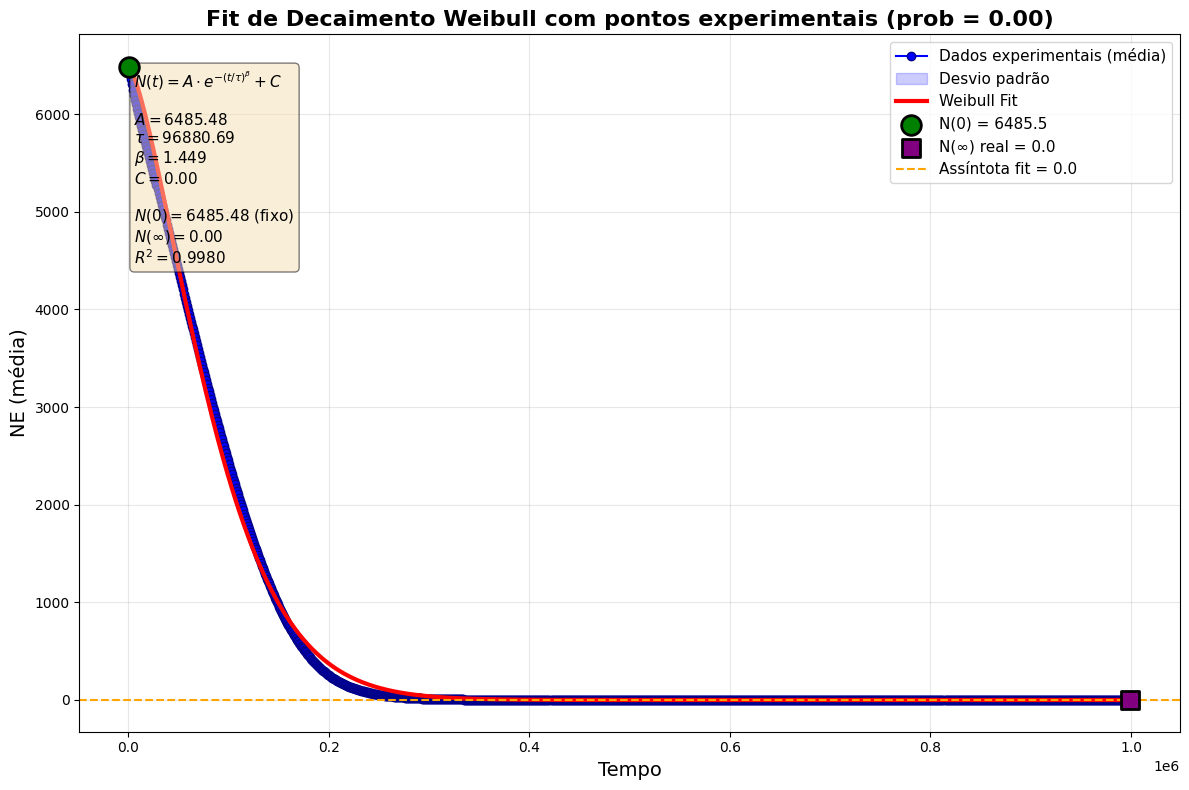


RESULTADOS DO FIT COM PONTOS VISÍVEIS - prob = 0.00
Parâmetros encontrados:
  A = 6485.4800
  τ = 96880.6869
  β = 1.4490
  C = 0.0000
  R² = 0.9980


In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Probabilidade específica
prob = 0.0

# Número de runs
num_runs = 100

# Carregar dados
todos_dados_NE = []
tempos = []

print(f"Carregando dados para prob = {prob:.2f}...")

for run in range(1, num_runs + 1):
    try:
        caminho = f"{base_path}simulation_frac_25run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
        df = pd.read_csv(caminho)
        df_cortado = df.iloc[1:].reset_index(drop=True)
        col_NE = [col for col in df_cortado.columns if col != 'time'][0]
        
        valores = df_cortado[col_NE].values
        tempo = df_cortado['time'].values
        
        todos_dados_NE.append(valores)
        tempos.append(tempo)
    except:
        continue

if todos_dados_NE:
    # Encontrar o menor comprimento
    min_len = min(len(arr) for arr in todos_dados_NE)
    
    # Cortar todos os arrays
    todos_dados_NE_cortados = [arr[:min_len] for arr in todos_dados_NE]
    todos_dados_NE_array = np.array(todos_dados_NE_cortados)
    
    # Calcular média
    media = np.mean(todos_dados_NE_array, axis=0)
    desvio = np.std(todos_dados_NE_array, axis=0)
    tempo = tempos[0][:min_len]
    
    # Função de decaimento Weibull com N(0) fixo
    def weibull_decay_fixed_initial(t, tau, beta, C):
        """Força que N(0) = media[0] (primeiro ponto dos dados)"""
        A = media[0] - C
        return A * np.exp(-(t / tau)**beta) + C
    
    # Chutes iniciais
    C_guess = max(media[-1], 0)  # Garantir não negativo
    tau_guess = tempo[len(tempo)//2]
    beta_guess = 1.5
    
    # Fazer o fit com N(0) fixo e C >= 0
    try:
        popt, pcov = curve_fit(weibull_decay_fixed_initial, tempo, media,
                              p0=[tau_guess, beta_guess, C_guess],
                              bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
                              maxfev=5000)
        
        tau_fit, beta_fit, C_fit = popt
        A_fit = media[0] - C_fit
        
        # Garantir valores físicos
        C_fit = max(C_fit, 0)
        A_fit = max(A_fit, 0)
        
        # Gerar curva ajustada
        tempo_fit = np.linspace(min(tempo), max(tempo), 500)
        media_fit = A_fit * np.exp(-(tempo_fit / tau_fit)**beta_fit) + C_fit
        
        # Calcular R²
        residuos = media - (A_fit * np.exp(-(tempo / tau_fit)**beta_fit) + C_fit)
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((media - np.mean(media))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Plotar gráfico COM PONTOS
        plt.figure(figsize=(12, 8))
        
        # Pontos da média (com marcadores)
        plt.plot(tempo, media, 'bo-', label='Dados experimentais (média)', 
                 markersize=6, linewidth=1.5, markerfacecolor='blue', 
                 markeredgecolor='darkblue', markeredgewidth=1)
        
        # Banda de desvio padrão
        plt.fill_between(tempo, media - desvio, media + desvio, 
                         alpha=0.2, color='blue', label='Desvio padrão')
        
        # Curva do fit (sem pontos, apenas linha)
        plt.plot(tempo_fit, media_fit, 'r-', linewidth=3, label=f'Weibull Fit')
        
        # Destacar ponto inicial
        plt.scatter(tempo[0], media[0], color='green', s=200, zorder=5, 
                   edgecolors='black', linewidths=2, 
                   label=f'N(0) = {media[0]:.1f}')
        
        # Destacar ponto final
        plt.scatter(tempo[-1], media[-1], color='purple', s=150, zorder=5, 
                   edgecolors='black', linewidths=2, marker='s',
                   label=f'N(∞) real = {media[-1]:.1f}')
        
        # Destacar assíntota do fit
        plt.axhline(y=C_fit, color='orange', linestyle='--', linewidth=1.5,
                   label=f'Assíntota fit = {C_fit:.1f}')
        
        plt.xlabel('Tempo', fontsize=14)
        plt.ylabel('NE (média)', fontsize=14)
        plt.title(f'Fit de Decaimento Weibull com pontos experimentais (prob = {prob:.2f})', 
                  fontsize=16, fontweight='bold')
        plt.legend(fontsize=11, loc='best')
        plt.grid(True, alpha=0.3)
        
        # Texto com parâmetros
        textstr = f'$N(t) = A \\cdot e^{{-(t/\\tau)^{{\\beta}}}} + C$\n\n' \
                  f'$A = {A_fit:.2f}$\n' \
                  f'$\\tau = {tau_fit:.2f}$\n' \
                  f'$\\beta = {beta_fit:.3f}$\n' \
                  f'$C = {C_fit:.2f}$\n\n' \
                  f'$N(0) = {media[0]:.2f}$ (fixo)\n' \
                  f'$N(\\infty) = {C_fit:.2f}$\n' \
                  f'$R^2 = {r_squared:.4f}$'
        
        plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
                 fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*70)
        print(f"RESULTADOS DO FIT COM PONTOS VISÍVEIS - prob = {prob:.2f}")
        print("="*70)
        print(f"Parâmetros encontrados:")
        print(f"  A = {A_fit:.4f}")
        print(f"  τ = {tau_fit:.4f}")
        print(f"  β = {beta_fit:.4f}")
        print(f"  C = {C_fit:.4f}")
        print(f"  R² = {r_squared:.4f}")
        print("="*70)
        
    except Exception as e:
        print(f"Erro no fit: {e}")

Carregando dados para prob = 1.00...


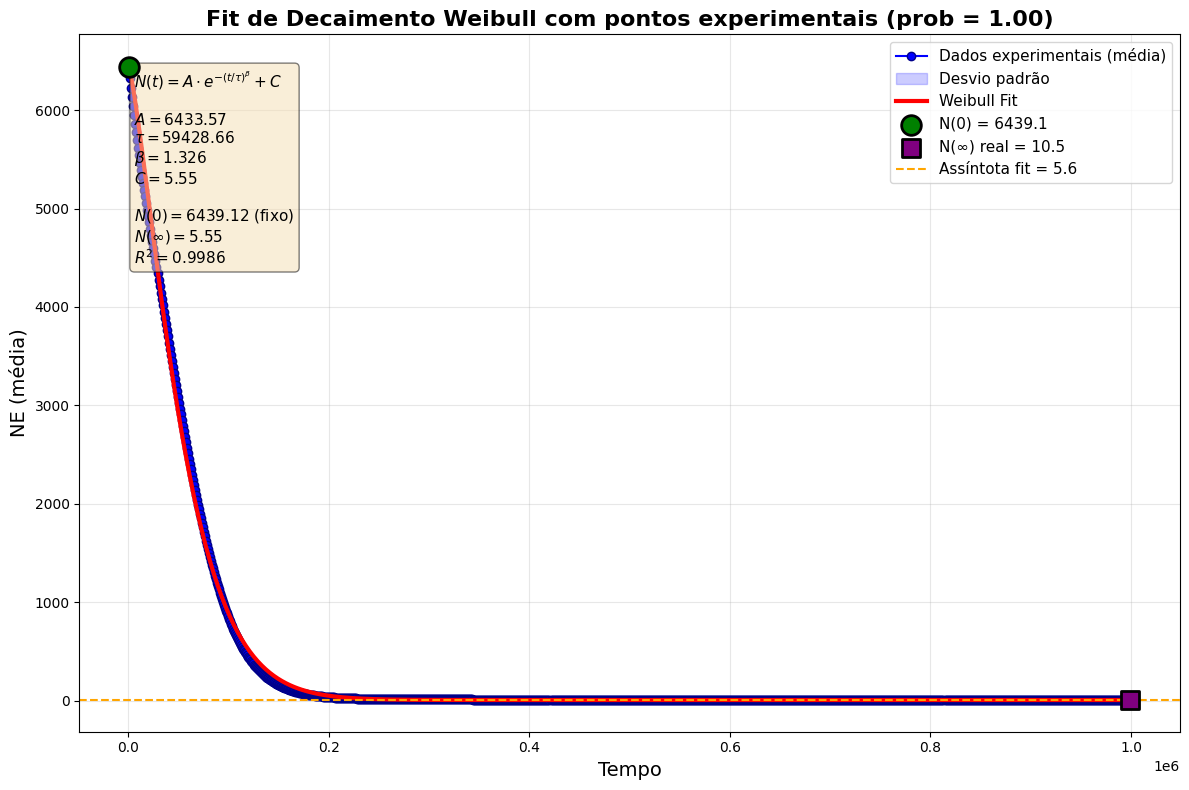


RESULTADOS DO FIT COM PONTOS VISÍVEIS - prob = 1.00
Parâmetros encontrados:
  A = 6433.5691
  τ = 59428.6621
  β = 1.3258
  C = 5.5509
  R² = 0.9986


In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Probabilidade específica
prob = 1.00

# Número de runs
num_runs = 100

# Carregar dados
todos_dados_NE = []
tempos = []

print(f"Carregando dados para prob = {prob:.2f}...")

for run in range(1, num_runs + 1):
    try:
        caminho = f"{base_path}simulation_frac_50run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
        df = pd.read_csv(caminho)
        df_cortado = df.iloc[1:].reset_index(drop=True)
        col_NE = [col for col in df_cortado.columns if col != 'time'][0]
        
        valores = df_cortado[col_NE].values
        tempo = df_cortado['time'].values
        
        todos_dados_NE.append(valores)
        tempos.append(tempo)
    except:
        continue

if todos_dados_NE:
    # Encontrar o menor comprimento
    min_len = min(len(arr) for arr in todos_dados_NE)
    
    # Cortar todos os arrays
    todos_dados_NE_cortados = [arr[:min_len] for arr in todos_dados_NE]
    todos_dados_NE_array = np.array(todos_dados_NE_cortados)
    
    # Calcular média
    media = np.mean(todos_dados_NE_array, axis=0)
    desvio = np.std(todos_dados_NE_array, axis=0)
    tempo = tempos[0][:min_len]
    
    # Função de decaimento Weibull com N(0) fixo
    def weibull_decay_fixed_initial(t, tau, beta, C):
        """Força que N(0) = media[0] (primeiro ponto dos dados)"""
        A = media[0] - C
        return A * np.exp(-(t / tau)**beta) + C
    
    # Chutes iniciais
    C_guess = max(media[-1], 0)  # Garantir não negativo
    tau_guess = tempo[len(tempo)//2]
    beta_guess = 1.5
    
    # Fazer o fit com N(0) fixo e C >= 0
    try:
        popt, pcov = curve_fit(weibull_decay_fixed_initial, tempo, media,
                              p0=[tau_guess, beta_guess, C_guess],
                              bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
                              maxfev=5000)
        
        tau_fit, beta_fit, C_fit = popt
        A_fit = media[0] - C_fit
        
        # Garantir valores físicos
        C_fit = max(C_fit, 0)
        A_fit = max(A_fit, 0)
        
        # Gerar curva ajustada
        tempo_fit = np.linspace(min(tempo), max(tempo), 500)
        media_fit = A_fit * np.exp(-(tempo_fit / tau_fit)**beta_fit) + C_fit
        
        # Calcular R²
        residuos = media - (A_fit * np.exp(-(tempo / tau_fit)**beta_fit) + C_fit)
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((media - np.mean(media))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Plotar gráfico COM PONTOS
        plt.figure(figsize=(12, 8))
        
        # Pontos da média (com marcadores)
        plt.plot(tempo, media, 'bo-', label='Dados experimentais (média)', 
                 markersize=6, linewidth=1.5, markerfacecolor='blue', 
                 markeredgecolor='darkblue', markeredgewidth=1)
        
        # Banda de desvio padrão
        plt.fill_between(tempo, media - desvio, media + desvio, 
                         alpha=0.2, color='blue', label='Desvio padrão')
        
        # Curva do fit (sem pontos, apenas linha)
        plt.plot(tempo_fit, media_fit, 'r-', linewidth=3, label=f'Weibull Fit')
        
        # Destacar ponto inicial
        plt.scatter(tempo[0], media[0], color='green', s=200, zorder=5, 
                   edgecolors='black', linewidths=2, 
                   label=f'N(0) = {media[0]:.1f}')
        
        # Destacar ponto final
        plt.scatter(tempo[-1], media[-1], color='purple', s=150, zorder=5, 
                   edgecolors='black', linewidths=2, marker='s',
                   label=f'N(∞) real = {media[-1]:.1f}')
        
        # Destacar assíntota do fit
        plt.axhline(y=C_fit, color='orange', linestyle='--', linewidth=1.5,
                   label=f'Assíntota fit = {C_fit:.1f}')
        
        plt.xlabel('Tempo', fontsize=14)
        plt.ylabel('NE (média)', fontsize=14)
        plt.title(f'Fit de Decaimento Weibull com pontos experimentais (prob = {prob:.2f})', 
                  fontsize=16, fontweight='bold')
        plt.legend(fontsize=11, loc='best')
        plt.grid(True, alpha=0.3)
        
        # Texto com parâmetros
        textstr = f'$N(t) = A \\cdot e^{{-(t/\\tau)^{{\\beta}}}} + C$\n\n' \
                  f'$A = {A_fit:.2f}$\n' \
                  f'$\\tau = {tau_fit:.2f}$\n' \
                  f'$\\beta = {beta_fit:.3f}$\n' \
                  f'$C = {C_fit:.2f}$\n\n' \
                  f'$N(0) = {media[0]:.2f}$ (fixo)\n' \
                  f'$N(\\infty) = {C_fit:.2f}$\n' \
                  f'$R^2 = {r_squared:.4f}$'
        
        plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
                 fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*70)
        print(f"RESULTADOS DO FIT COM PONTOS VISÍVEIS - prob = {prob:.2f}")
        print("="*70)
        print(f"Parâmetros encontrados:")
        print(f"  A = {A_fit:.4f}")
        print(f"  τ = {tau_fit:.4f}")
        print(f"  β = {beta_fit:.4f}")
        print(f"  C = {C_fit:.4f}")
        print(f"  R² = {r_squared:.4f}")
        print("="*70)
        
    except Exception as e:
        print(f"Erro no fit: {e}")

  A = 6440.1300
  τ = 57247.8532
  β = 1.3427
  C = 0.0000
  R² = 0.9987